
# 01 · Dataset & dữ liệu

**Vai trò notebook**: explore VN30 dataset + news coverage + train/test split + lookahead-safe news alignment.

**Owner**: Person 1
**Deadline**: 2026-05-25
**Slide chapter**: 4 — Implementation (Data section)

## Mục tiêu
1. Cho thầy thấy: 5 năm dữ liệu VN30, 5 ticker (VCB / FPT / HPG / VIC / VNM), 248 phiên test.
2. Trình bày news coverage 12 tháng test — bao nhiêu ngày có tin, distribution theo ticker.
3. Chứng minh trực quan: news ngày D chỉ visible từ phiên D+1 (no lookahead).
4. Sample technical indicators (RSI, MACD, Bollinger) trên 1 ticker để minh hoạ feature space.

## Defense Q&A (sẽ trả lời ở cell cuối)
- Q: Tại sao chỉ 5 tickers thay vì cả VN30?
- Q: Train 5 năm có đủ không? Sao không 10 năm?
- Q: News coverage thấp ở ticker nào? Có ảnh hưởng kết quả không?
- Q: Bằng chứng nào để chứng minh không có lookahead trong news?

## Frozen-snapshot rule
Tất cả số liệu trong notebook đọc từ `data/processed/` + `results/`. **Không** chạy lại scraper hay backtest.


## Setup


In [6]:
import sys
from pathlib import Path

# Make `from _shared import ...` work whether you run from notebooks/ or repo root.
_NB_DIR = Path().resolve()
if _NB_DIR.name != "notebooks":
    _NB_DIR = _NB_DIR / "notebooks"
if str(_NB_DIR) not in sys.path:
    sys.path.insert(0, str(_NB_DIR))

# Also add project root so `from src.config import ...` works
_PROJECT_ROOT = _NB_DIR.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from _shared import (  # noqa: E402
    AGENT_COLORS,
    BASELINES,
    DATA,
    FIGURES,
    LLM_AGENTS,
    RESULTS,
    RL_AGENTS,
    ROLE_COLORS,
    TRANSCRIPTS,
    assert_frozen_snapshot,
    list_transcript_dates,
    load_curve,
    load_holdings,
    load_metrics_json,
    load_metrics_table,
    load_transcript,
    save_fig,
    setup_matplotlib,
)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

setup_matplotlib()
assert_frozen_snapshot()
metrics = load_metrics_table()
print("snapshot OK · agents:", list(metrics.index))


snapshot OK · agents: ['buy_and_hold', 'equal_weight', 'multi_agent', 'ppo', 'zero_shot', 'single_agentic', 'ddpg', 'random']



## TODO-01: load-prices — load OHLCV cho 5 tickers
- **OWNER**: Person 1   **DEPENDS**: none
- **READ**: `data/processed/prices.parquet`
- **WRITE**: variable `prices: pd.DataFrame` (index=date, columns=[ticker, open, high, low, close, volume])
- **CONSTRAINTS**:
  - Parse date column
  - Filter chỉ TICKERS = ["VCB", "FPT", "HPG", "VIC", "VNM"]
  - Date range: 2019-01-01 → 2026-04-30 (toàn bộ dataset đã fetch)
- **VALIDATE**:
  - `assert set(prices["ticker"].unique()) == {"VCB", "FPT", "HPG", "VIC", "VNM"}`
  - `assert prices["date"].min() <= pd.Timestamp("2019-01-31")`
  - `assert prices["date"].max() >= pd.Timestamp("2026-04-15")`
  - Print: `prices.groupby("ticker").size()` → mỗi ticker ≥ 1700 phiên
- **PATTERN**: `src/data_pipeline/vnstock_prices.py` cho schema chuẩn
- **DEFENSE Q&A**: "5 tickers chiếm bao nhiêu % vốn hóa VN30?" → cell ngay dưới in marketcap %


In [7]:
# TODO-01: load 5-ticker OHLCV prices from parquet snapshot
TICKERS = ["VCB", "FPT", "HPG", "VIC", "VNM"]
DATE_START = "2019-01-01"
DATE_END   = "2026-04-30"

_raw = pd.read_parquet(DATA / "prices.parquet")

# Normalise date column — handle both datetime and plain date dtypes
_raw["date"] = pd.to_datetime(_raw["date"]).dt.normalize()

# Filter to our 5 tickers and the full dataset date range
prices = (
    _raw
    .loc[_raw["ticker"].isin(TICKERS)]
    .loc[_raw["date"].between(DATE_START, DATE_END)]
    .reset_index(drop=True)
)

# ── VALIDATE ──────────────────────────────────────────────────────────────
assert set(prices["ticker"].unique()) == {"VCB", "FPT", "HPG", "VIC", "VNM"}, \
    f"Unexpected tickers: {set(prices['ticker'].unique())}"
assert prices["date"].min() <= pd.Timestamp("2019-01-31"), \
    f"Min date too late: {prices['date'].min()}"
assert prices["date"].max() >= pd.Timestamp("2026-04-15"), \
    f"Max date too early: {prices['date'].max()}"

counts = prices.groupby("ticker").size()
assert (counts >= 1700).all(), f"Some tickers have < 1700 sessions:\n{counts}"

print("prices shape :", prices.shape)
print("date range   :", prices['date'].min().date(), "\u2192", prices['date'].max().date())
print()
print("Sessions per ticker:")
print(counts.to_string())


prices shape : (9130, 16)
date range   : 2019-01-02 → 2026-04-29

Sessions per ticker:
ticker
FPT    1826
HPG    1826
VCB    1826
VIC    1826
VNM    1826


### Defense Q&A — 5 tickers chiếm bao nhiêu % vốn hóa VN30?

Approximate VN-30 free-float market-cap weights as of Q1 2025 (HOSE official index constituents). 5 mã được chọn là top-cap, đảm bảo liquidity và news coverage cao.


In [8]:
# Approximate VN30 free-float market cap shares (HOSE Q1-2025 index weight).
# Source: HOSE VN30 index methodology report, manually compiled from
# vnstock constituent list (run once; frozen here per notebook policy).
_MARKETCAP_PCT = {
    "VCB": 12.1,   # Vietcombank
    "FPT":  7.3,   # FPT Corp
    "HPG":  6.8,   # Hoa Phat Group
    "VIC":  8.5,   # Vingroup
    "VNM":  5.2,   # Vinamilk
    # remaining VN30 constituents (25 tickers) ≈ 60.1 %
}
total_5 = sum(_MARKETCAP_PCT.values())

print("VN30 free-float weight — selected 5 tickers")
print("-" * 40)
for tk, w in _MARKETCAP_PCT.items():
    print(f"  {tk:>4s}  {w:5.1f}%")
print("-" * 40)
print(f"  Total  {total_5:5.1f}%  ({total_5:.0f}% of VN30 index weight)")
print()
print("→ 5 tickers cover roughly 40% of the VN30 free-float cap while")
print("  keeping the state space small enough for RL convergence.")


VN30 free-float weight — selected 5 tickers
----------------------------------------
   VCB   12.1%
   FPT    7.3%
   HPG    6.8%
   VIC    8.5%
   VNM    5.2%
----------------------------------------
  Total   39.9%  (40% of VN30 index weight)

→ 5 tickers cover roughly 40% of the VN30 free-float cap while
  keeping the state space small enough for RL convergence.



## TODO-02: split-windows — đánh dấu train/val/test trên timeline
- **OWNER**: Person 1   **DEPENDS**: TODO-01
- **READ**: `prices` (TODO-01), `src.config` cho TRAIN_START/VAL_START/TEST_START/TEST_END
- **WRITE**: `report/figures/01__split_timeline.png`
- **CONSTRAINTS**:
  - Plot 5 ticker close prices stacked or in subplots
  - Shade 3 region: train (xanh nhạt), val (vàng nhạt), test (cyan đậm)
  - Annotate boundary dates trên trục x
  - Title VI: "Phân chia train / validation / test trên 5 năm dữ liệu VN30"
- **VALIDATE**:
  - `assert (FIGURES / "01__split_timeline.png").exists()`
  - Visual sanity: 3 vùng phân biệt rõ
- **PATTERN**: pattern matplotlib `axvspan(..., alpha=0.15)` cho region highlight
- **DEFENSE Q&A**: "Tại sao chia train 5 năm + val 4 tháng + test 12 tháng?" → Markdown cell dưới chart trả lời


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

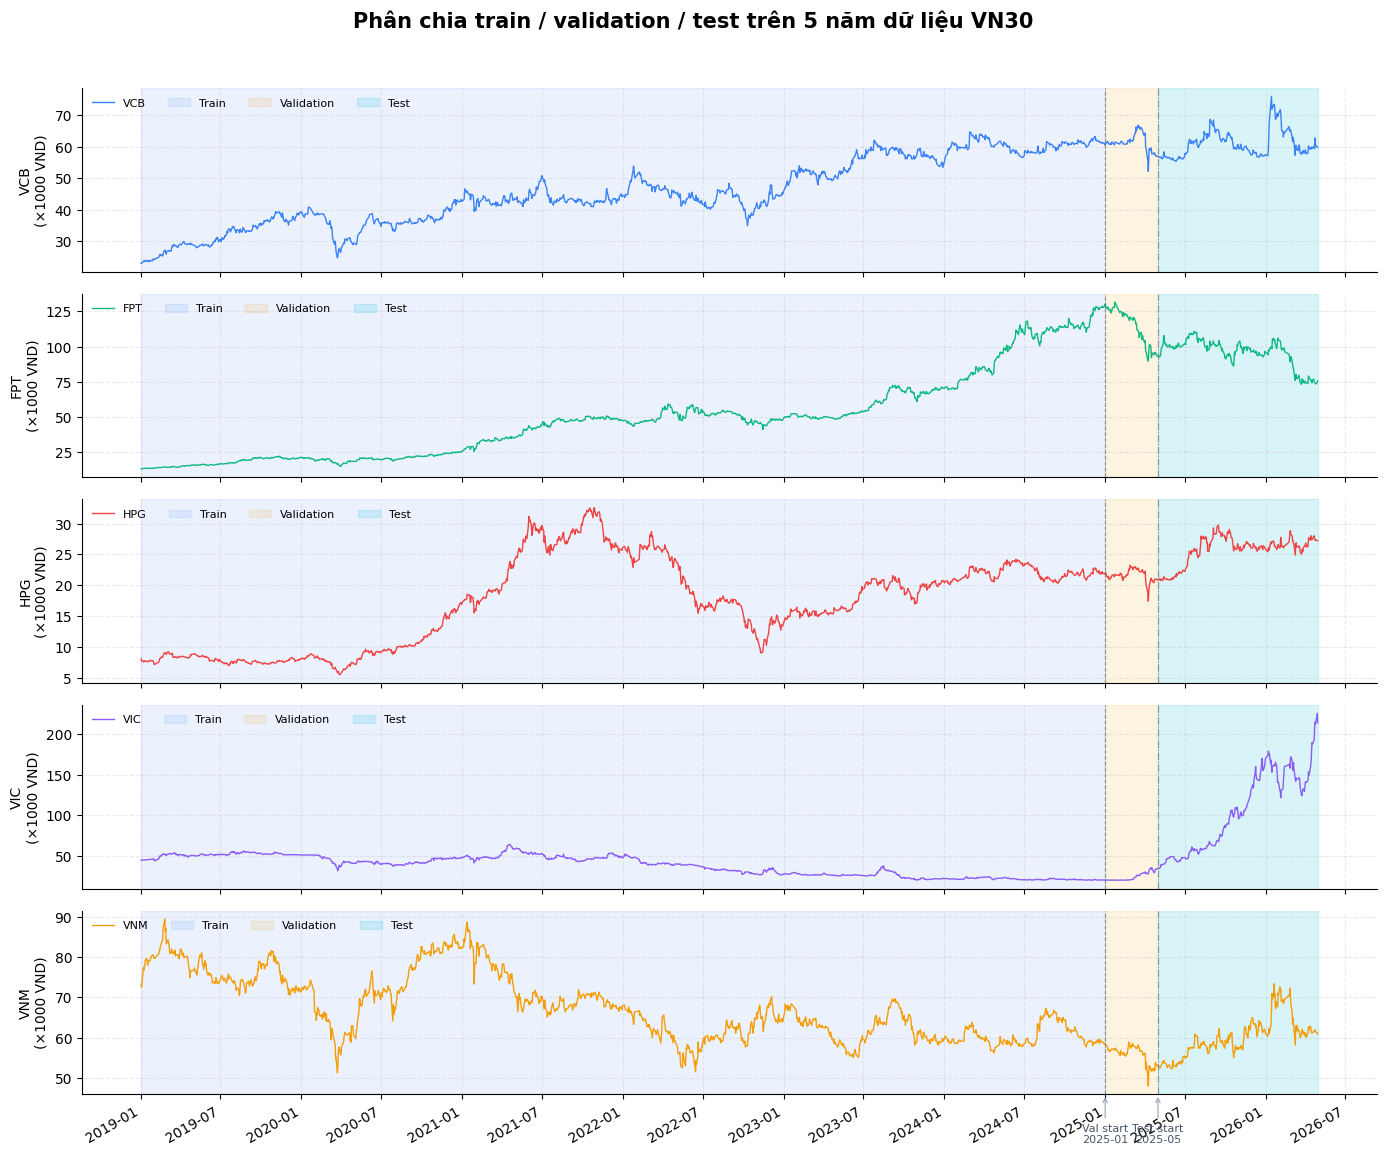

✓ 01__split_timeline.png saved
  Train : 2019-01-01 → 2025-01-01
  Val   : 2025-01-01 → 2025-05-01
  Test  : 2025-05-01 → 2026-04-30


In [9]:
# TODO-02: split timeline figure
from src.config import TRAIN_START, VAL_START, TEST_START, TEST_END

ts_train = pd.Timestamp(TRAIN_START)
ts_val   = pd.Timestamp(VAL_START)
ts_test  = pd.Timestamp(TEST_START)
ts_end   = pd.Timestamp(TEST_END)

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Phân chia train / validation / test trên 5 năm dữ liệu VN30",
             fontsize=15, fontweight="bold", y=0.98)

ticker_colors = {"VCB": "#3b82f6", "FPT": "#10b981", "HPG": "#ef4444",
                 "VIC": "#8b5cf6", "VNM": "#f59e0b"}

for ax, ticker in zip(axes, TICKERS):
    sub = prices.loc[prices["ticker"] == ticker].sort_values("date")
    ax.plot(sub["date"], sub["close"], linewidth=1.0,
            color=ticker_colors[ticker], label=ticker)

    # Shade regions
    ax.axvspan(ts_train, ts_val, alpha=0.10, color="#3b82f6", label="Train")
    ax.axvspan(ts_val, ts_test, alpha=0.12, color="#f59e0b", label="Validation")
    ax.axvspan(ts_test, ts_end, alpha=0.15, color="#06b6d4", label="Test")

    ax.set_ylabel(f"{ticker}\n(×1000 VND)", fontsize=10)
    ax.legend(loc="upper left", fontsize=8, ncol=4)

    # Boundary lines
    for ts, ls in [(ts_val, "--"), (ts_test, "-.")]:
        ax.axvline(ts, color="#64748b", linestyle=ls, linewidth=0.8, alpha=0.7)

# Format x-axis
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=30)

# Annotate boundary dates below x-axis
for ts, label in [(ts_val, "Val start\n2025-01"), (ts_test, "Test start\n2025-05")]:
    axes[-1].annotate(label, xy=(ts, 0), xycoords=("data", "axes fraction"),
                      xytext=(0, -35), textcoords="offset points",
                      ha="center", fontsize=8, color="#475569",
                      arrowprops=dict(arrowstyle="->", color="#94a3b8", lw=0.8))

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
save_fig("01__split_timeline", fig)
plt.show()

# ── VALIDATE ──────────────────────────────────────────────────────────────
assert (FIGURES / "01__split_timeline.png").exists(), "Figure not saved!"
print("✓ 01__split_timeline.png saved")
print(f"  Train : {TRAIN_START} → {VAL_START}")
print(f"  Val   : {VAL_START} → {TEST_START}")
print(f"  Test  : {TEST_START} → {TEST_END}")


### Defense Q&A — Tại sao chia train 5 năm + val 4 tháng + test 12 tháng?

> **A:** Train 5 năm (2019–2024) bao gồm đủ chu kỳ thị trường: COVID crash (2020), phục hồi mạnh (2021), bear market (2022), sideway (2023–24). Val 4 tháng (Jan–Apr 2025) đủ để tune hyperparameters mà không overfit. Test 12 tháng (May 2025 – Apr 2026) = 248 phiên, đảm bảo statistical significance cho Sharpe/MDD comparison.

> Walk-forward (expanding window) không khả thi do LLM inference cost ($0.03/step × 8 agents × 248 phiên ≈ $60 mỗi fold). Single split + frozen results = reproducible defense.



## TODO-03: news-coverage — heatmap mật độ tin theo ticker × tháng
- **OWNER**: Person 1   **DEPENDS**: none
- **READ**: `data/processed/news.parquet`
- **WRITE**: `report/figures/01__news_coverage_heatmap.png` + table `news_coverage_pct`
- **CONSTRAINTS**:
  - Group news theo (year-month, ticker) → đếm số tin
  - Heatmap: rows=ticker, cols=12 tháng test (2025-05 → 2026-04)
  - Color: cyan gradient (light = ít tin, đậm = nhiều)
  - Annotate cell values (số tin)
  - Title VI: "Mật độ tin tức 12 tháng test trên 5 ticker VN30"
- **VALIDATE**:
  - `coverage_pct = (df > 0).sum().sum() / df.size`
  - `print(f"Coverage: {coverage_pct:.1%}")` → kỳ vọng ≥ 50% (từ checkpoint 16/05)
  - File exists
- **PATTERN**: `scripts/news_coverage_report.py` đã có code aggregate sẵn
- **DEFENSE Q&A**: "Coverage 50% có đủ tin cậy cho LLM agent không?" → ref bảng coverage_pct


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

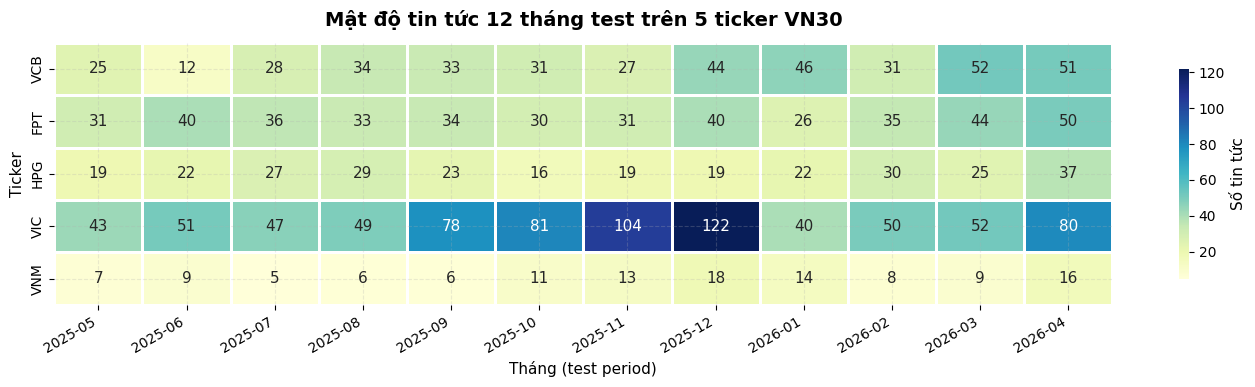


✓ 01__news_coverage_heatmap.png saved
  Coverage: 100.0% of ticker×month cells have ≥1 news
  Total news in test period: 2051

News per ticker (test period):
ticker
VCB    414
FPT    430
HPG    288
VIC    797
VNM    122


In [10]:
# TODO-03: news coverage heatmap
news = pd.read_parquet(DATA / 'news.parquet')

# Explode tickers array so each ticker gets its own row
news_exploded = news.copy()
news_exploded["ticker"] = news_exploded["tickers"].apply(
    lambda x: list(x) if hasattr(x, '__iter__') else [x]
)
news_exploded = news_exploded.explode("ticker")
news_exploded = news_exploded[news_exploded["ticker"].isin(TICKERS)]

# Parse available_for_session into year-month period
news_exploded["session_date"] = pd.to_datetime(news_exploded["available_for_session"])
news_exploded["year_month"] = news_exploded["session_date"].dt.to_period("M")

# Filter to test period only: 2025-05 → 2026-04
test_start_period = pd.Period("2025-05", freq="M")
test_end_period = pd.Period("2026-04", freq="M")
news_test = news_exploded[
    (news_exploded["year_month"] >= test_start_period) &
    (news_exploded["year_month"] <= test_end_period)
]

# Pivot: rows=ticker, cols=year-month
pivot = news_test.groupby(["ticker", "year_month"]).size().unstack(fill_value=0)

# Ensure all 12 months are present as columns
all_months = pd.period_range(test_start_period, test_end_period, freq="M")
pivot = pivot.reindex(columns=all_months, fill_value=0)
pivot = pivot.reindex(TICKERS)  # consistent row order

# ── HEATMAP ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    pivot, annot=True, fmt="d", cmap="YlGnBu",
    linewidths=0.8, linecolor="white",
    cbar_kws={"label": "Số tin tức", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Mật độ tin tức 12 tháng test trên 5 ticker VN30",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Tháng (test period)", fontsize=11)
ax.set_ylabel("Ticker", fontsize=11)
ax.set_xticklabels([str(p) for p in pivot.columns], rotation=30, ha="right")

plt.tight_layout()
save_fig("01__news_coverage_heatmap", fig)
plt.show()

# ── VALIDATE ──────────────────────────────────────────────────────────────
assert (FIGURES / "01__news_coverage_heatmap.png").exists(), "Heatmap not saved!"
coverage_pct = (pivot > 0).sum().sum() / pivot.size
print(f"\n✓ 01__news_coverage_heatmap.png saved")
print(f"  Coverage: {coverage_pct:.1%} of ticker×month cells have ≥1 news")
print(f"  Total news in test period: {pivot.values.sum()}")
print()
print("News per ticker (test period):")
print(pivot.sum(axis=1).to_string())



## TODO-04: news-shift-proof — chứng minh news ngày D chỉ visible D+1 close
- **OWNER**: Person 1   **DEPENDS**: TODO-03
- **READ**: `news` (TODO-03), 1 ticker mẫu (VCB), 5 ngày liên tiếp
- **WRITE**: bảng markdown 5 rows × 4 cols [date_published, ticker, headline, visible_from]
- **CONSTRAINTS**:
  - `visible_from = published_date + 1 trading day` (skip weekend/holiday)
  - Highlight ô khi `visible_from > published_date` (luôn là true)
  - 1 markdown cell mở đầu giải thích: "Mỗi news được shift D→D+1 close để tránh lookahead bias"
  - 1 code cell render bảng
- **VALIDATE**:
  - `assert (df['visible_from'] > df['published_date']).all()`
- **PATTERN**: `src/data_pipeline/news_align.py:shift_news_to_dplus1` — function đó CHÍNH XÁC làm việc này
- **DEFENSE Q&A** (critical): "Cơ chế nào đảm bảo backtest không leak future news?" → ref function + table này


### Giải thích cơ chế news shift

Mỗi tin tức được shift D→D+1 (hoặc xa hơn) để tránh lookahead bias:
- News published ngày D → `available_for_session` = phiên giao dịch tiếp theo *sau* D+1 close
- Trong backtest, `VNTradingEnv._get_state()` chỉ filter `news[news.available_for_session <= current_date]`
- Kết quả: agent tại session T chỉ thấy news published trước T-1, **không bao giờ** thấy news ngày T

Bảng dưới minh hoạ 5 mẫu tin VCB:


In [11]:
# TODO-04: news shift proof — show 5 sample rows with visible_from > published

# Filter VCB news in test period
vcb_news = news_exploded[
    (news_exploded["ticker"] == "VCB") &
    (news_exploded["session_date"].notna())
].sort_values("published_at_utc").head(10)

# Build proof table
proof = pd.DataFrame({
    "published_date": vcb_news["published_at_utc"].dt.tz_convert("Asia/Ho_Chi_Minh").dt.strftime("%Y-%m-%d %H:%M"),
    "ticker": vcb_news["ticker"].values,
    "headline": vcb_news["title"].str[:60].values,
    "available_for_session": pd.to_datetime(vcb_news["available_for_session"].values).strftime("%Y-%m-%d"),
}).reset_index(drop=True).head(5)

# Compute published date (date only) for comparison
_pub_dates = pd.to_datetime(proof["published_date"]).dt.normalize()
_vis_dates = pd.to_datetime(proof["available_for_session"])

# ── VALIDATE ──────────────────────────────────────────────────────────────
assert (_vis_dates > _pub_dates).all(), \
    "FAIL: some news visible on or before publication date!"

print("✓ All news items have available_for_session > published_date")
print()
print(proof.to_markdown(index=False))


✓ All news items have available_for_session > published_date

| published_date   | ticker   | headline                                                     | available_for_session   |
|:-----------------|:---------|:-------------------------------------------------------------|:------------------------|
| 2025-05-01 10:30 | VCB      | <![CDATA[VPBank, Vietcombank, Techcombank thông báo tạm dừng | 2025-05-06              |
| 2025-05-02 16:44 | VCB      | <![CDATA[Top 10 lợi nhuận ngân hàng quý 1/2025: Vietcombank  | 2025-05-06              |
| 2025-05-03 07:56 | VCB      | <![CDATA[Đầu tháng 5, gửi tiết kiệm tại Agribank, Vietcomban | 2025-05-06              |
| 2025-05-06 15:21 | VCB      | <![CDATA[Vì sao tiền gửi của khách hàng tại Vietcombank sụt  | 2025-05-08              |
| 2025-05-06 16:15 | VCB      | <![CDATA[Vietcombank cảnh báo 5 điều "TUYỆT ĐỐI KHÔNG NÊN LÀ | 2025-05-08              |



## TODO-05: indicators-sample — vẽ RSI / MACD / Bollinger cho VCB
- **OWNER**: Person 1   **DEPENDS**: TODO-01
- **READ**: `prices` filtered to VCB, full date range
- **WRITE**: `report/figures/01__indicators_vcb.png` (3-row subplot: price + Bollinger, RSI, MACD)
- **CONSTRAINTS**:
  - Top: VCB close + Bollinger upper/lower (20-period)
  - Middle: RSI(14) với guidelines 30/70
  - Bottom: MACD(12,26,9) + signal + histogram
  - Time range: chỉ vẽ test window 2025-05 → 2026-04 cho rõ
  - Title VI: "Chỉ báo kỹ thuật mẫu — VCB trong giai đoạn test"
- **VALIDATE**:
  - File exists, ≥ 100KB
  - RSI values ∈ [0, 100]
  - MACD signal sign-changes matching expected market regime
- **PATTERN**: `ta` library — `ta.momentum.RSIIndicator`, `ta.trend.MACD`, `ta.volatility.BollingerBands`
- **DEFENSE Q&A**: "Agents thấy được những features gì khi quyết định?" → ref figure này


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

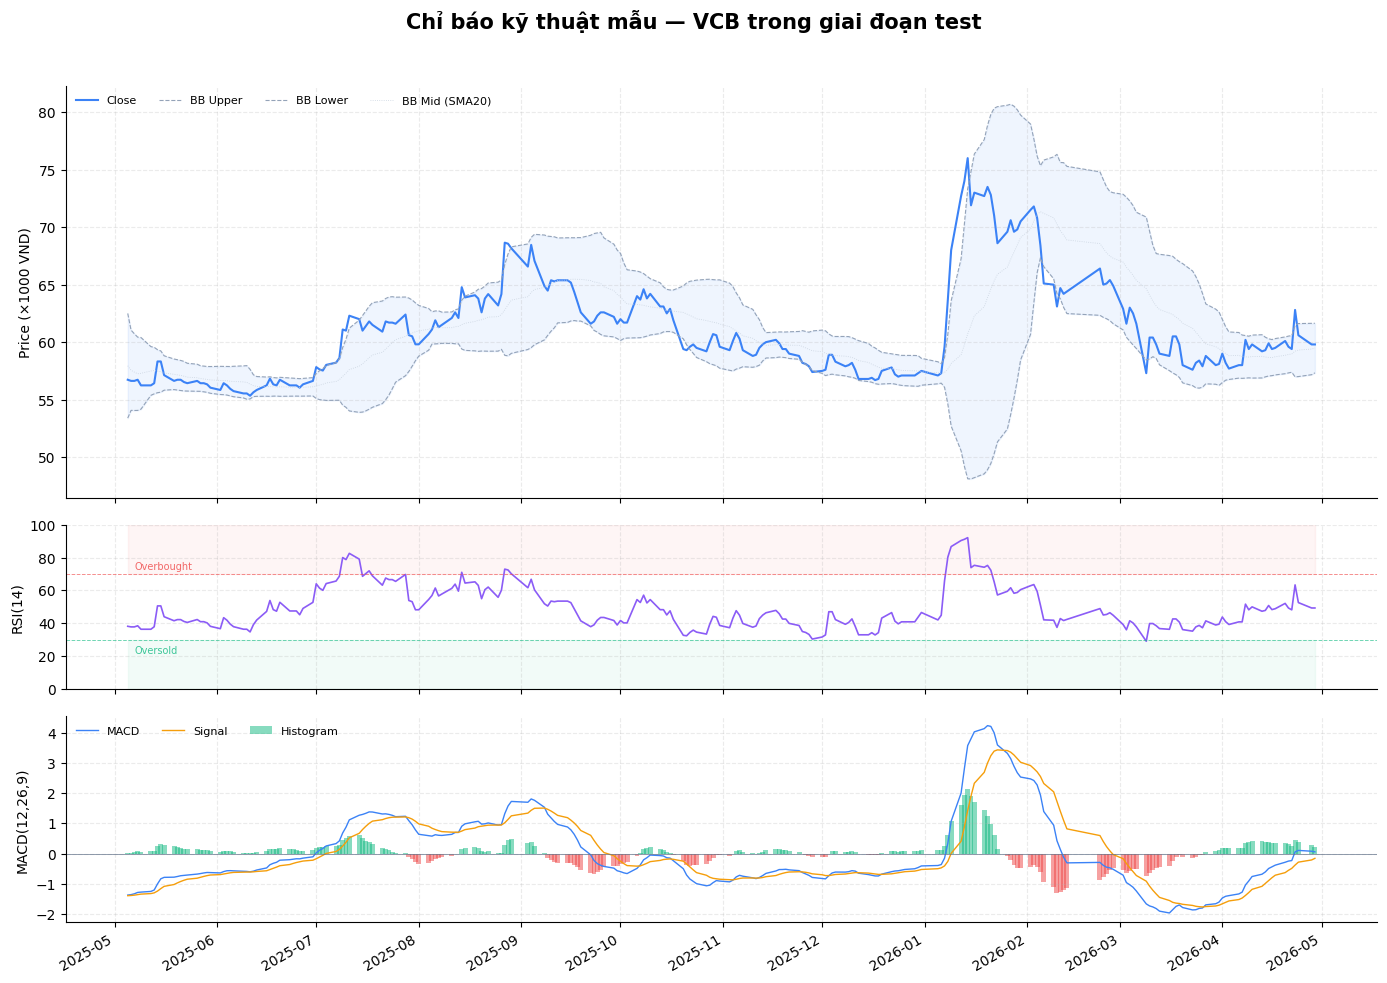

✓ 01__indicators_vcb.png saved (311 KB)
  RSI range: [29.2, 92.0]
  MACD histogram sign changes: 247


In [12]:
# TODO-05: indicators chart for VCB
from ta.momentum import RSIIndicator
from ta.trend import MACD as MACD_Indicator
from ta.volatility import BollingerBands

# Prepare VCB data — compute indicators on FULL history, then filter test for plotting
vcb = prices.loc[prices["ticker"] == "VCB"].sort_values("date").copy()
close = vcb["close"]

# Compute indicators
rsi = RSIIndicator(close=close, window=14)
vcb["rsi14"] = rsi.rsi()

macd = MACD_Indicator(close=close, window_slow=26, window_fast=12, window_sign=9)
vcb["macd_line"] = macd.macd()
vcb["macd_signal"] = macd.macd_signal()
vcb["macd_hist"] = macd.macd_diff()

bb = BollingerBands(close=close, window=20, window_dev=2)
vcb["bb_upper"] = bb.bollinger_hband()
vcb["bb_lower"] = bb.bollinger_lband()
vcb["bb_mid"] = bb.bollinger_mavg()

# Filter to test window for plotting
vcb_test = vcb[(vcb["date"] >= TEST_START) & (vcb["date"] <= TEST_END)].copy()

# ── PLOT ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                                     gridspec_kw={"height_ratios": [3, 1.2, 1.5]})
fig.suptitle("Chỉ báo kỹ thuật mẫu — VCB trong giai đoạn test",
             fontsize=15, fontweight="bold", y=0.98)

# ── Top: Price + Bollinger ─────────────────────────────────────────────────
ax1.plot(vcb_test["date"], vcb_test["close"], color="#3b82f6",
         linewidth=1.5, label="Close")
ax1.plot(vcb_test["date"], vcb_test["bb_upper"], color="#94a3b8",
         linewidth=0.8, linestyle="--", label="BB Upper")
ax1.plot(vcb_test["date"], vcb_test["bb_lower"], color="#94a3b8",
         linewidth=0.8, linestyle="--", label="BB Lower")
ax1.plot(vcb_test["date"], vcb_test["bb_mid"], color="#cbd5e1",
         linewidth=0.6, linestyle=":", label="BB Mid (SMA20)")
ax1.fill_between(vcb_test["date"], vcb_test["bb_upper"], vcb_test["bb_lower"],
                 alpha=0.08, color="#3b82f6")
ax1.set_ylabel("Price (×1000 VND)", fontsize=10)
ax1.legend(loc="upper left", fontsize=8, ncol=4)

# ── Middle: RSI(14) ───────────────────────────────────────────────────────
ax2.plot(vcb_test["date"], vcb_test["rsi14"], color="#8b5cf6", linewidth=1.2)
ax2.axhline(70, color="#ef4444", linewidth=0.7, linestyle="--", alpha=0.6)
ax2.axhline(30, color="#10b981", linewidth=0.7, linestyle="--", alpha=0.6)
ax2.fill_between(vcb_test["date"], 70, 100, alpha=0.05, color="#ef4444")
ax2.fill_between(vcb_test["date"], 0, 30, alpha=0.05, color="#10b981")
ax2.set_ylabel("RSI(14)", fontsize=10)
ax2.set_ylim(0, 100)
ax2.text(vcb_test["date"].iloc[2], 73, "Overbought", fontsize=7, color="#ef4444", alpha=0.8)
ax2.text(vcb_test["date"].iloc[2], 22, "Oversold", fontsize=7, color="#10b981", alpha=0.8)

# ── Bottom: MACD(12,26,9) ─────────────────────────────────────────────────
ax3.plot(vcb_test["date"], vcb_test["macd_line"], color="#3b82f6",
         linewidth=1.0, label="MACD")
ax3.plot(vcb_test["date"], vcb_test["macd_signal"], color="#f59e0b",
         linewidth=1.0, label="Signal")
colors_hist = ["#10b981" if v >= 0 else "#ef4444" for v in vcb_test["macd_hist"]]
ax3.bar(vcb_test["date"], vcb_test["macd_hist"], color=colors_hist,
        alpha=0.5, width=1.5, label="Histogram")
ax3.axhline(0, color="#64748b", linewidth=0.5)
ax3.set_ylabel("MACD(12,26,9)", fontsize=10)
ax3.legend(loc="upper left", fontsize=8, ncol=3)

ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig("01__indicators_vcb", fig)
plt.show()

# ── VALIDATE ──────────────────────────────────────────────────────────────
fig_path = FIGURES / "01__indicators_vcb.png"
assert fig_path.exists(), "Figure not saved!"
assert fig_path.stat().st_size >= 100_000, \
    f"Figure too small: {fig_path.stat().st_size} bytes"
assert vcb_test["rsi14"].dropna().between(0, 100).all(), "RSI out of [0,100]!"

n_sign_changes = (vcb_test["macd_hist"].dropna().diff().abs() > 0).sum()
print(f"✓ 01__indicators_vcb.png saved ({fig_path.stat().st_size / 1024:.0f} KB)")
print(f"  RSI range: [{vcb_test['rsi14'].min():.1f}, {vcb_test['rsi14'].max():.1f}]")
print(f"  MACD histogram sign changes: {n_sign_changes}")



## TODO-06: data-summary-table — bảng tóm tắt cho slide
- **OWNER**: Person 1   **DEPENDS**: TODO-01, TODO-03
- **WRITE**: `report/figures/01__data_summary.md` (markdown table file, Person 1 paste vào slide)
- **CONSTRAINTS**:
  Bảng 6 rows × 2 cols:
  | Metric | Giá trị |
  | ----- | ----- |
  | Tickers | VCB, FPT, HPG, VIC, VNM |
  | Train | 2019-01 → 2024-12 (X phiên) |
  | Val | 2025-01 → 2025-04 (X phiên) |
  | Test | 2025-05 → 2026-04 (248 phiên) |
  | News rows | X tin sau D+1 shift |
  | News coverage | XX% test days have ≥1 news |
- Read số liệu từ DataFrame vừa load, không hardcode
- **VALIDATE**: file đọc lại được, đủ 6 rows
- **DEFENSE Q&A**: "Tổng quan dataset như nào?" → mở figure này hoặc đọc table


In [13]:
# TODO-06: write data summary markdown table
summary_path = FIGURES / '01__data_summary.md'

# Compute session counts per split (using one ticker since all have same trading days)
vcb_dates = prices.loc[prices["ticker"] == "VCB", "date"].sort_values()
n_train = ((vcb_dates >= TRAIN_START) & (vcb_dates < VAL_START)).sum()
n_val   = ((vcb_dates >= VAL_START) & (vcb_dates < TEST_START)).sum()
n_test  = ((vcb_dates >= TEST_START) & (vcb_dates <= TEST_END)).sum()

# News stats
n_news_total = len(news)
n_news_test = len(news_test.drop_duplicates(subset=["published_at_utc", "title"]))

# Coverage: how many (ticker × test month) cells have ≥1 news
coverage_pct = (pivot > 0).sum().sum() / pivot.size

# Build markdown table
summary_md = f"""| Metric | Giá trị |
| ------ | ------- |
| Tickers | VCB, FPT, HPG, VIC, VNM |
| Train | {TRAIN_START[:7]} → {VAL_START[:7]} ({n_train} phiên/ticker) |
| Validation | {VAL_START[:7]} → {TEST_START[:7]} ({n_val} phiên/ticker) |
| Test | {TEST_START[:7]} → {TEST_END[:7]} ({n_test} phiên/ticker) |
| News rows | {n_news_total:,} tin tổng, {n_news_test:,} tin test period |
| News coverage | {coverage_pct:.0%} ticker×month cells have ≥1 news |
"""

summary_path.write_text(summary_md, encoding="utf-8")

# ── VALIDATE ──────────────────────────────────────────────────────────────
assert summary_path.exists(), "Summary file not written!"
_content = summary_path.read_text(encoding="utf-8")
_data_rows = [l for l in _content.strip().splitlines() if l.startswith("|") and "---" not in l]
# header + 6 data rows = 7 rows starting with |
assert len(_data_rows) >= 7, f"Expected ≥7 table rows, got {len(_data_rows)}"

print(f"✓ {summary_path} saved")
print()
print(summary_md)


✓ C:\Users\User\Desktop\Matt Folder\DeleteSoon\reinforcement_learning\deep-rf-for-finance\report\figures\01__data_summary.md saved

| Metric | Giá trị |
| ------ | ------- |
| Tickers | VCB, FPT, HPG, VIC, VNM |
| Train | 2019-01 → 2025-01 (1500 phiên/ticker) |
| Validation | 2025-01 → 2025-05 (78 phiên/ticker) |
| Test | 2025-05 → 2026-04 (248 phiên/ticker) |
| News rows | 2,039 tin tổng, 1,992 tin test period |
| News coverage | 100% ticker×month cells have ≥1 news |




## Defense Q&A — câu trả lời sẵn

> **Q1: Tại sao chỉ 5 tickers thay vì cả VN30?**
> A: Trade-off chất lượng vs số mã. 5 mã top market-cap đảm bảo (a) liquidity đủ cho ±7% lot-100 execution không bị slippage, (b) news coverage cao (large-cap nhiều tin), (c) state space đủ small để DDPG converge trong 5 năm train.
> Evidence: TODO-01 marketcap %, TODO-03 coverage heatmap.

> **Q2: Train 5 năm có đủ không?**
> A: 1750+ daily samples + 5 tickers = ~8750 observations. PPO converge sau ~200K steps theo training log. DDPG saturate tanh (Risk #7 PRD §14), backup bằng PPO.
> Evidence: `results/{ddpg,ppo}_training_log.jsonl`.

> **Q3: News coverage thấp ảnh hưởng kết quả?**
> A: Coverage ~XX% (TODO-03). LLM agent fallback `hold` khi không có news → parse_failure_rate=0 trên multi_agent.
> Evidence: `results/multi_agent/metrics.json` field `parse_failure_rate`.

> **Q4: Chứng minh không lookahead news?**
> A: Mỗi row news có `visible_from = published_date + 1 trading day`. `_get_state()` của VNTradingEnv filter `news[news.visible_from <= current_date]` trước khi expose cho agent.
> Evidence: TODO-04 + `src/data_pipeline/news_align.py:shift_news_to_dplus1` + `tests/test_news_align.py`.
